Enter number of processes: 5

Page Sizes (Process Requirements):
P1: 3
P2: 9
P3: 2
P4: 7
P5: 10

Enter total number of frames: 20
Enter minimum frames (threshold) per process: 3

===== Allocation Menu =====
1. Minimum Allocation
2. Equal Allocation
3. Proportional Allocation
4. Exit
Enter your choice: 1

Minimum Allocation Done

Process	Frames Allocated
P1	3
P2	3
P3	3
P4	3
P5	3


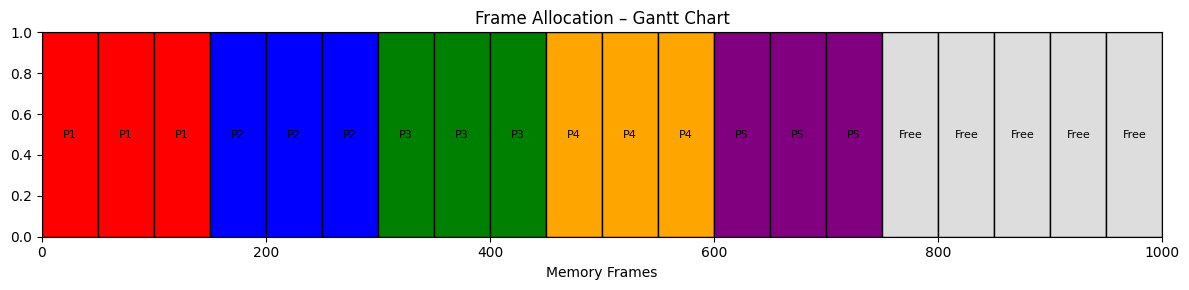


===== Allocation Menu =====
1. Minimum Allocation
2. Equal Allocation
3. Proportional Allocation
4. Exit


KeyboardInterrupt: Interrupted by user

In [ ]:
import random
import matplotlib.pyplot as plt


# ---------------- Gantt Chart (Dynamic Partitions) ----------------
def plot_gantt(frames):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches

    total_frames = len(frames)
    frame_width = 50
    total_memory = total_frames * frame_width

    fig, ax = plt.subplots(figsize=(12, 3))

    unique_pids = sorted(set(frames))
    colors = {}

    # Fixed color list
    color_list = ["red", "blue", "green", "orange", "purple", "cyan"]

    for i, pid in enumerate(unique_pids):
        if pid == 0:
            colors[pid] = "#dddddd"  # Free memory
        else:
            colors[pid] = color_list[(i - 1) % len(color_list)]

    start = 0

    for pid in frames:
        rect = patches.Rectangle(
            (start, 0), frame_width, 1,
            edgecolor='black',
            facecolor=colors[pid]
        )
        ax.add_patch(rect)

        label = "Free" if pid == 0 else f"P{pid}"
        ax.text(start + frame_width / 2, 0.5, label,
                ha='center', va='center', fontsize=8)

        start += frame_width

    # Formatting
    ax.set_xlim(0, total_memory)
    ax.set_ylim(0, 1)
    #ax.set_yticks([])

    ax.set_xlabel("Memory Frames")
    ax.set_title("Frame Allocation – Gantt Chart")

    plt.tight_layout()
    plt.show()


# ---------------- Allocation Helper ----------------
def allocate(frames, counts):
    for i in range(len(frames)):
        frames[i] = 0

    idx = 0
    for pid, cnt in enumerate(counts, start=1):
        for _ in range(cnt):
            if idx >= len(frames):
                return
            frames[idx] = pid
            idx += 1


# ---------------- Allocation Methods ----------------
def minimum_allocation(frames, threshold, n):
    counts = [threshold] * n
    allocate(frames, counts)
    return counts

def equal_allocation(frames, threshold, n):
    total_frames = len(frames)

    # Step 1: calculate remaining frames
    remaining = total_frames - (threshold * n)

    # Step 2: base frames for each process
    base = remaining // n
    extra = remaining % n

    # Step 3: initialize counts
    counts = []
    for i in range(n):
        counts.append(threshold + base)

    # Step 4: distribute extra frames one by one
    for i in range(extra):
        counts[i] = counts[i] + 1

    # Step 5: allocate frames
    allocate(frames, counts)

    return counts

def proportional_allocation(frames, page_sizes, threshold):
    total_frames = len(frames)
    n = len(page_sizes)

    # Step 1: remaining frames after minimum allocation
    remaining = total_frames - (threshold * n)

    # Step 2: total page requirement
    total_req = sum(page_sizes)

    # Step 3: initial allocation
    counts = []
    for i in range(n):
        share = (page_sizes[i] * remaining) // total_req
        counts.append(threshold + share)

    # Step 4: calculate leftover frames
    used = 0
    for i in range(n):
        used += (counts[i] - threshold)

    leftover = remaining - used

    # Step 5: calculate fractions (for fair distribution)
    fractions = []
    for i in range(n):
        exact = (page_sizes[i] * remaining) / total_req
        fraction = exact - int(exact)
        fractions.append(fraction)

    # Step 6: distribute leftover based on highest fraction
    # Step 1: store (fraction, index)
    pairs = []
    for i in range(n):
        pairs.append((fractions[i], i))

    # Step 2: sort in descending order
    pairs.sort(reverse=True)

    # Step 3: give leftover frames
    for i in range(leftover):
        index = pairs[i][1]
        counts[index] += 1

    # Step 7: allocate frames
    allocate(frames, counts)

    return counts


# ---------------- Menu Program ----------------
def main():

    n = int(input("Enter number of processes: "))
    page_sizes = [random.randint(1, 10) for _ in range(n)]

    print("\nPage Sizes (Process Requirements):")
    for i, s in enumerate(page_sizes, 1):
        print(f"P{i}: {s}")

    total_frames = int(input("\nEnter total number of frames: "))
    frames = [0] * total_frames

    threshold = int(input("Enter minimum frames (threshold) per process: "))

    if threshold * n > total_frames:
        print("Allocation not possible with given threshold")
        return

    while True:
        print("\n===== Allocation Menu =====")
        print("1. Minimum Allocation")
        print("2. Equal Allocation")
        print("3. Proportional Allocation")
        print("4. Exit")

        choice = int(input("Enter your choice: "))

        if choice == 1:
            counts = minimum_allocation(frames, threshold, n)
            print("\nMinimum Allocation Done")

        elif choice == 2:
            counts = equal_allocation(frames, threshold, n)
            print("\nEqual Allocation Done")

        elif choice == 3:
            counts = proportional_allocation(frames, page_sizes, threshold)
            print("\nProportional Allocation Done")

        elif choice == 4:
            print("Exiting Program...")
            break

        else:
            print("Invalid Choice!")
            continue

        print("\nProcess\tFrames Allocated")
        for i, c in enumerate(counts, 1):
            print(f"P{i}\t{c}")

        plot_gantt(frames)


if __name__ == "__main__":
    main()